<font size="+3"><strong>4.2. Predicting Damage with Logistic Regression</strong></font>

In [1]:
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from IPython.display import VimeoVideo
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

INTRO
We are classify into two classes based on damage, Logistic Regression is used for Classification, we are going to explain odds-ratio
Exploration - class balance, randomised train-test aplit
Model Building - Baseline - accuracy score, Iterate - Logistic Regression, Evaluation - Accuracy Score
Communication - Odds Ratio

In [2]:
def wrangle(db_path):
    # Connect to database
    conn = sqlite3.connect(db_path)

    # Construct query
    query = """
        SELECT distinct(i.building_id) AS b_id,
           s.*,
           d.damage_grade
        FROM id_map AS i
        JOIN building_structure AS s ON i.building_id = s.building_id
        JOIN building_damage AS d ON i.building_id = d.building_id
        WHERE district_id = 4
    """

    # Read query results into DataFrame
    df = pd.read_sql(query,conn, index_col="b_id")

    
    return df

In [12]:
def wrangle():
    df = pd.read_csv("data/earthquake_damage.csv")
    
    return df

In [5]:
df = wrangle()
df.head()

,building_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,condition_post_eq,superstructure,damage_grade
0,164002,3,3,20,560,18,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Repaired and used,"Stone, mud mortar",Grade 2
1,164081,2,2,21,200,12,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Used in risk,"Stone, mud mortar",Grade 2
2,164089,3,3,18,315,20,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Used in risk,"Stone, mud mortar",Grade 2
3,164098,2,2,45,290,13,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Used in risk,"Stone, mud mortar",Grade 3
4,164103,2,2,21,230,13,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Used in risk,"Stone, mud mortar",Grade 3


In [11]:
#IDENTIFY LEAKY COLUMNS -> columns having post_eq -> post earthquake reading will be a give away for predictions
# drop_cols = []
# for col in df.columns:
#       if "post_eq" in col:
#         drop_cols.append(col)
drop_cols = [col for col in df.columns if "post_eq" in col]
drop_cols

['count_floors_post_eq', 'height_ft_post_eq', 'condition_post_eq']

In [15]:
def wrangle():
    df = pd.read_csv("data/earthquake_damage.csv")

    # Rename 'building_id' to 'b_id'
    df.rename(columns={"building_id": "b_id"}, inplace=True)

    # Set 'b_id' as index
    df.set_index("b_id", inplace=True)

    # Identify and remove leaky features
    drop_cols = [col for col in df.columns if "post_eq" in col]
    df.drop(columns=drop_cols, inplace=True)

    return df

In [16]:
df = wrangle()
df.head()

,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,superstructure,damage_grade
b_id,,,,,,,,,,,,,
164002,3,20,560,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",Grade 2
164081,2,21,200,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",Grade 2
164089,3,18,315,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",Grade 2
164098,2,45,290,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",Grade 3
164103,2,21,230,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",Grade 3


In [17]:
print(df["damage_grade"].value_counts())

damage_grade
Grade 5    24869
Grade 4    20650
Grade 3    14097
Grade 2     7650
Grade 1     3570
Name: count, dtype: int64


In [18]:
# We'll consider Grade 5 and 4 (severely damaged) as postive class of 1 and other as 0 
#df['damage_grade'] = df["damage_grade"].str[-1].astype(int)
#df['severe_damage'] = (df['damage_grade'] > 3).astype(int)

In [20]:
def wrangle():
    df = pd.read_csv("data/earthquake_damage.csv")

    # Rename 'building_id' to 'b_id'
    df.rename(columns={"building_id": "b_id"}, inplace=True)

    # Set 'b_id' as index
    df.set_index("b_id", inplace=True)

    # Identify and remove leaky features
    drop_cols = [col for col in df.columns if "post_eq" in col]
    df.drop(columns=drop_cols, inplace=True)

    # Binary classification of target
    df['damage_grade'] = df["damage_grade"].str[-1].astype(int)
    df['severe_damage'] = (df['damage_grade'] > 3).astype(int)
    df.drop(columns=['damage_grade'], inplace=True)

    return df

In [25]:
df = wrangle()
df.head()

,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,superstructure,severe_damage
b_id,,,,,,,,,,,,,
164002,3,20,560,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164081,2,21,200,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164089,3,18,315,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164098,2,45,290,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164103,2,21,230,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0


In [26]:
#MULTI_COLLINEARITY
# Create correlation matrix
correlation = df.select_dtypes("number").drop(columns="severe_damage").corr()
correlation

,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq
count_floors_pre_eq,1.000000,0.063214,0.198433,0.740090
age_building,0.063214,1.000000,-0.016856,0.047652
plinth_area_sq_ft,0.198433,-0.016856,1.000000,0.283496
height_ft_pre_eq,0.740090,0.047652,0.283496,1.000000


<Axes: >

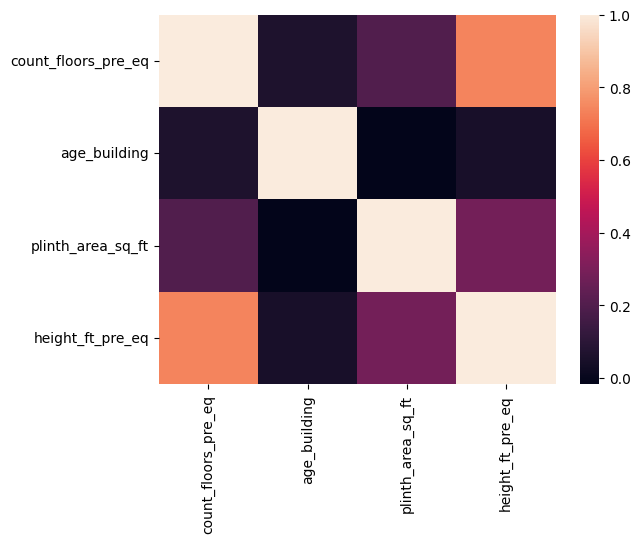

In [27]:
# Plot heatmap of `correlation`
sns.heatmap(correlation)

We can see count_floor and height of building are correlated with orange color...we need to decide which one to drop using correlation with target

In [28]:
df["severe_damage"].corr(df["count_floors_pre_eq"])

np.float64(0.002892630372575238)

In [29]:
df["severe_damage"].corr(df["height_ft_pre_eq"])

np.float64(-0.03847659083302036)

We are gonna drop first 'count_floors_pre_eq'

In [30]:
def wrangle():
    df = pd.read_csv("data/earthquake_damage.csv")

    # Rename 'building_id' to 'b_id'
    df.rename(columns={"building_id": "b_id"}, inplace=True)

    # Set 'b_id' as index
    df.set_index("b_id", inplace=True)

    # Identify and remove leaky features
    drop_cols = [col for col in df.columns if "post_eq" in col]
    df.drop(columns=drop_cols, inplace=True)

    # Binary classification of target
    df['damage_grade'] = df["damage_grade"].str[-1].astype(int)
    df['severe_damage'] = (df['damage_grade'] > 3).astype(int)
    df.drop(columns=['damage_grade'], inplace=True)

    #Multicollinearity Columns drop
    df.drop(columns=['count_floors_pre_eq'], inplace=True)


    return df

In [31]:
df = wrangle()
df.head()

,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,superstructure,severe_damage
b_id,,,,,,,,,,,,
164002,20,560,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164081,21,200,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164089,18,315,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164098,45,290,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164103,21,230,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0


Text(0.5, 1.0, 'Distribution of Building Height by Class')

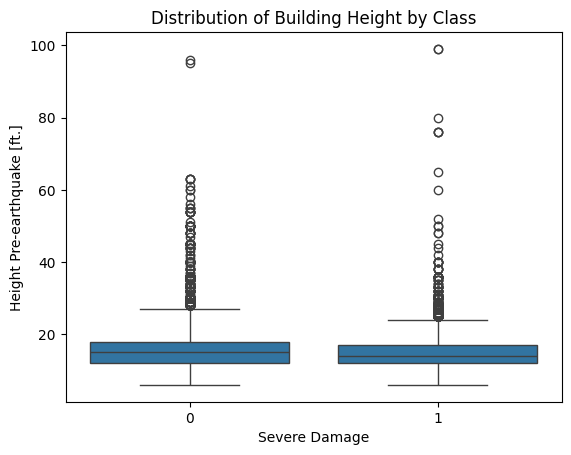

In [32]:
# Correlation between height(numerical) and damage(categorical) using seaborn
# Create boxplot
sns.boxplot(x="severe_damage",y="height_ft_pre_eq",data=df)
# Label axes
plt.xlabel("Severe Damage")
plt.ylabel("Height Pre-earthquake [ft.]")
plt.title("Distribution of Building Height by Class")

Here the box is bottom for 1 and also 0, best case would be where the box for 1 would have been on the top.

In [33]:
# Plot value counts of `"severe_damage"`
df["severe_damage"].value_counts()

severe_damage
1    45519
0    25317
Name: count, dtype: int64

In [34]:
# Plot value counts of `"severe_damage"`
df["severe_damage"].value_counts(normalize=True)

severe_damage
1    0.642597
0    0.357403
Name: proportion, dtype: float64

<Axes: title={'center': 'Class Balance'}, xlabel='Class', ylabel='Relative Frequency'>

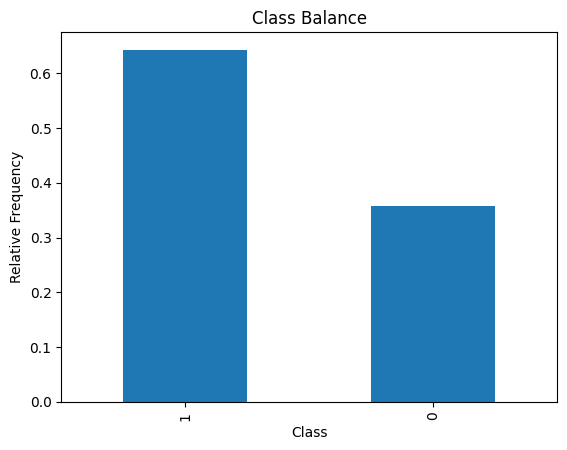

In [35]:
# Plot value counts of `"severe_damage"`
df["severe_damage"].value_counts(normalize=True).plot(
    kind="bar",xlabel="Class", ylabel="Relative Frequency", title="Class Balance"
)

1 is majority class and 0 is minority class..90/10 would be imbalance..but these are balanced enough!

In [36]:
majority_class_prop, minority_class_prop = df["severe_damage"].value_counts(normalize=True)
print(majority_class_prop, minority_class_prop)

0.6425969845841097 0.3574030154158902


In [37]:
# Create pivot table
foundation_pivot = pd.pivot_table(df,index="foundation_type",values="severe_damage",aggfunc=np.mean).sort_values(by="severe_damage")
foundation_pivot

,severe_damage
foundation_type,
RC,0.026224
Bamboo/Timber,0.324074
Cement-Stone/Brick,0.421908
Mud mortar-Stone/Brick,0.687792
Other,0.818898


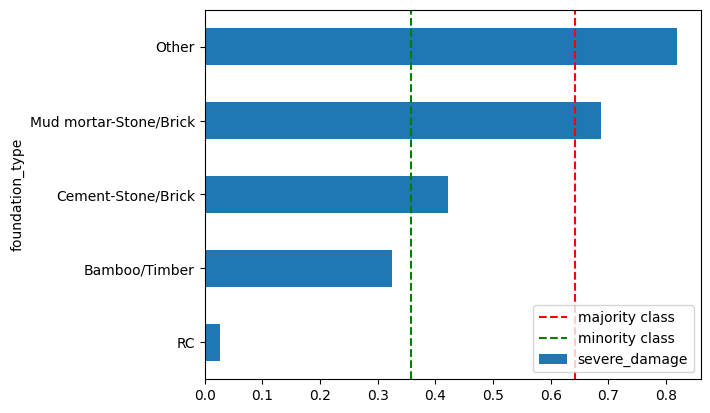

In [38]:
# Plot bar chart of `foundation_pivot`
# Create pivot table
foundation_pivot.plot(kind="barh")
plt.axvline(
    majority_class_prop, linestyle="--", color="red", label="majority class"
)
plt.axvline(
    minority_class_prop, linestyle="--", color="green", label="minority class"
)
plt.legend(loc="lower right")

Clearly we can see that Other has more damage and RC has low...this feature is distinguishing in nature for damage

In [43]:
def wrangle():
    df = pd.read_csv("data/earthquake_damage.csv")

    # Rename 'building_id' to 'b_id'
    df.rename(columns={"building_id": "b_id"}, inplace=True)

    # Set 'b_id' as index
    df.set_index("b_id", inplace=True)

    # Identify and remove leaky features
    drop_cols = [col for col in df.columns if "post_eq" in col]
    df.drop(columns=drop_cols, inplace=True)

    # Binary classification of target
    df['damage_grade'] = df["damage_grade"].str[-1].astype(int)
    df['severe_damage'] = (df['damage_grade'] > 3).astype(int)
    df.drop(columns=['damage_grade'], inplace=True)

    #Multicollinearity Columns drop
    df.drop(columns=['count_floors_pre_eq'], inplace=True)

    #High Cardinality
    #df.drop(columns=['building_id'],inplace=True) -> done for sqlite, renamed already for csv


    return df

In [44]:
df = wrangle();
df.head()

,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,superstructure,severe_damage
b_id,,,,,,,,,,,,
164002,20,560,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164081,21,200,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164089,18,315,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164098,45,290,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164103,21,230,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0


In [46]:
#Verticle split
target = "severe_damage"
X = df.drop(columns=target)
y = df[target]

In [47]:
X.head()

,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,superstructure
b_id,,,,,,,,,,,
164002,20,560,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar"
164081,21,200,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar"
164089,18,315,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar"
164098,45,290,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar"
164103,21,230,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar"


In [48]:
y.head()

b_id
164002    0
164081    0
164089    0
164098    0
164103    0
Name: severe_damage, dtype: int64

In [49]:
#TEST_TRAIN SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #42 is hitchiker's guide to galaxy reference standard

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (56668, 11)
y_train shape: (56668,)
X_test shape: (14168, 11)
y_test shape: (14168,)


Frequent Question: Why do we set the random state to 42?

Answer: The truth is you can pick any integer when setting a random state. The number you choose doesn't affect the results of your project; it just makes sure that your work is reproducible so that others can verify it. However, lots of people choose 42 because it appears in a well-known work of science fiction called The Hitchhiker's Guide to the Galaxy. In short, it's an inside joke. 😉

In [50]:
y_train.value_counts(normalize=True)

severe_damage
1    0.641032
0    0.358968
Name: proportion, dtype: float64

In [51]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.64


In [52]:
# Build model
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LogisticRegression(max_iter=1000)
)
# Fit model to training data
model.fit(X_train, y_train);

/Users/rajeshpolavarapu/Library/Caches/pypoetry/virtualenvs/earthquake-damage-prediction-model-9wdLqLVt-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [53]:
# Build model
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LogisticRegression(max_iter=10000)
)
# Fit model to training data
model.fit(X_train, y_train);

In [54]:
accuracy_score(y_train,model.predict(X_train))

0.7135949742359003

In [55]:
model.score(X_test,y_test)

0.722261434217956

In [56]:
acc_train = accuracy_score(y_train,model.predict(X_train))
acc_test = model.score(X_test,y_test)

print("Training Accuracy:", round(acc_train, 2))
print("Test Accuracy:", round(acc_test, 2))

Training Accuracy: 0.71
Test Accuracy: 0.72


In [57]:
model.predict(X_train[:5])

array([0, 1, 1, 1, 1])

In [58]:
y_train_pred_proba = model.predict_proba(X_train)
print(y_train_pred_proba[:5])

[[0.96737453 0.03262547]
 [0.48797152 0.51202848]
 [0.3461222  0.6538778 ]
 [0.39943492 0.60056508]
 [0.33220964 0.66779036]]


In [59]:
#FEATURES AND IMPORTANCES
features = model.named_steps["onehotencoder"].get_feature_names()
importances = model.named_steps["logisticregression"].coef_[0]

In [60]:
feat_imp = pd.Series(importances, index=features).sort_values()
feat_imp.head()

superstructure_Other                  -1.369451
superstructure_Brick, cement mortar   -1.095850
foundation_type_RC                    -0.991790
roof_type_RCC/RB/RBC                  -0.896627
superstructure_RC, engineered         -0.789154
dtype: float64

In [62]:
odds_ratios = pd.Series(np.exp(importances), index=features).sort_values()
odds_ratios.head()

superstructure_Other                   0.254247
superstructure_Brick, cement mortar    0.334255
foundation_type_RC                     0.370912
roof_type_RCC/RB/RBC                   0.407943
superstructure_RC, engineered          0.454229
dtype: float64

Text(0.5, 0, 'Odds Ratio')

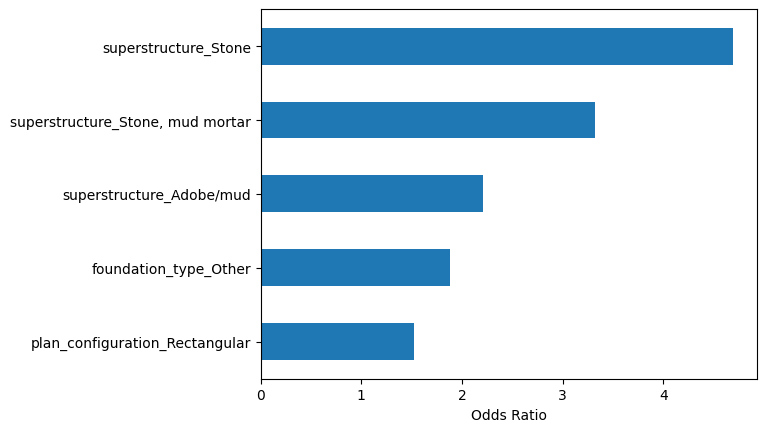

In [63]:
# Horizontal bar chart, five largest coefficients
odds_ratios.tail().plot(kind="barh")
plt.xlabel("Odds Ratio")

Text(0.5, 0, 'Odds Ratio')

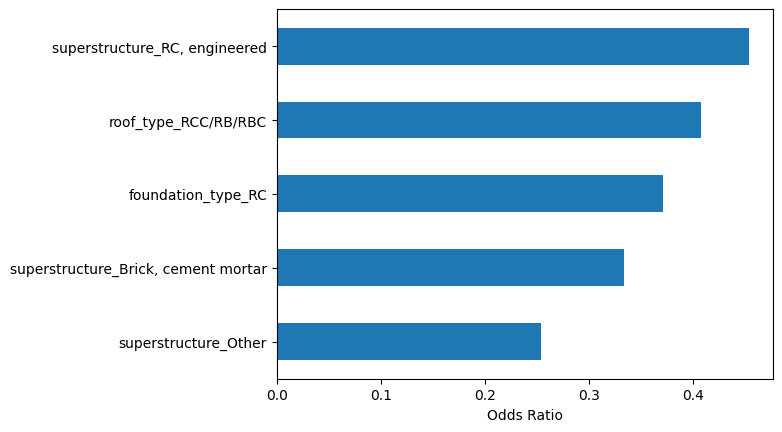

In [64]:
odds_ratios.head().plot(kind="barh")
plt.xlabel("Odds Ratio")